
# **Tesla Deliveries Forecasting (2015–2025)**

Analysis of Tesla's monthly delivery and production data from 2015 to 2025.

In [467]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (9, 4)

# **Load Data**
Read the dataset from CSV and work on a copy to preserve the original.

In [468]:
data=pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")
df=data.copy()

# **Exploratory Data Analysis (EDA)**


In [469]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [470]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [471]:
print(f"shape : {df.shape} , \ndatatype : \n{df.dtypes}")

shape : (2640, 12) , 
datatype : 
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [472]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


***Separating columns into numerical and categorical groups***


In [473]:
num_cols=["Estimated_Deliveries","Production_Units","Avg_Price_USD","Battery_Capacity_kWh"]
cate_cols=['Region','Model']

# Distribution & Outlier Analysis

***Histograms for all Numerical Columns***

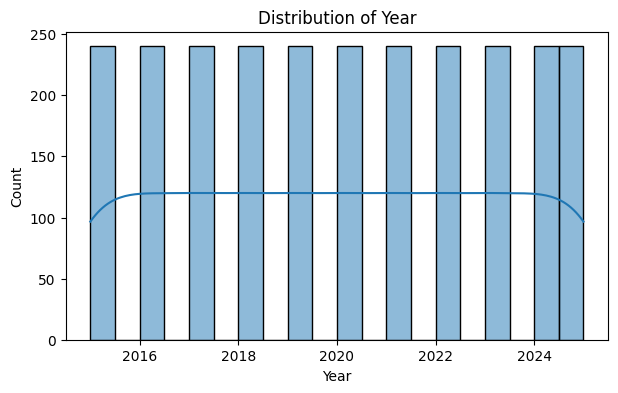

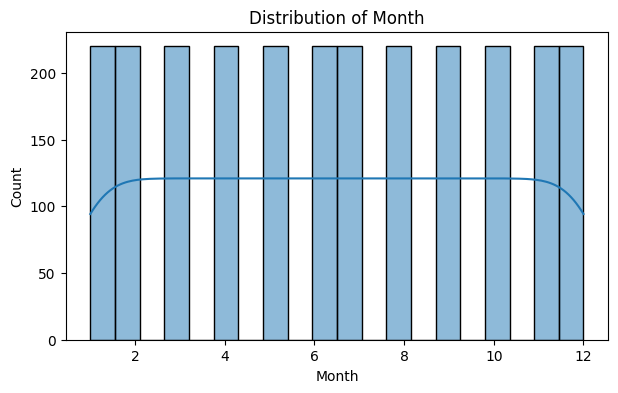

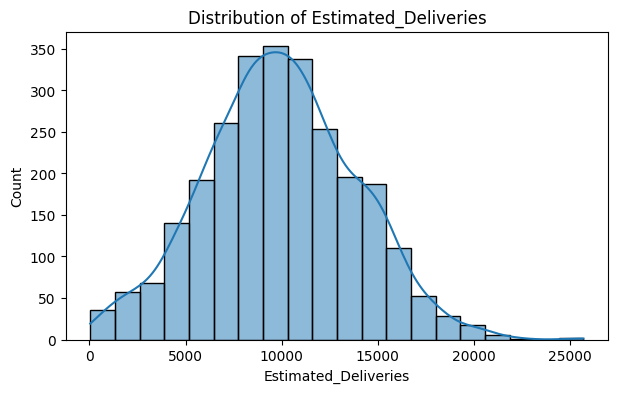

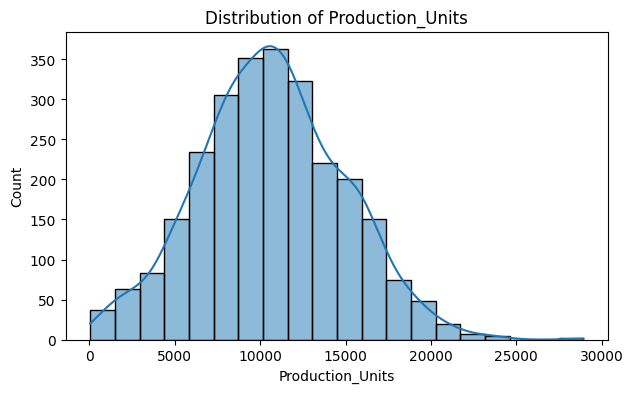

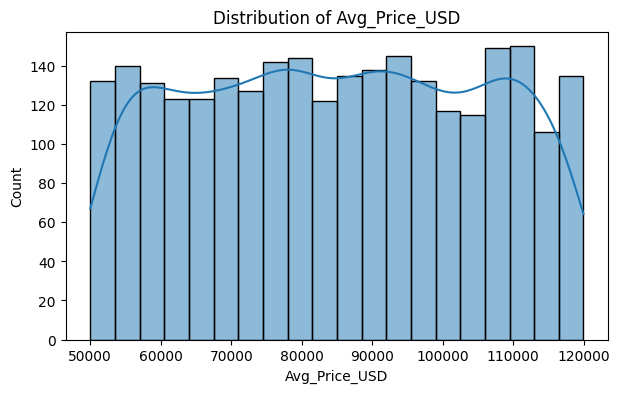

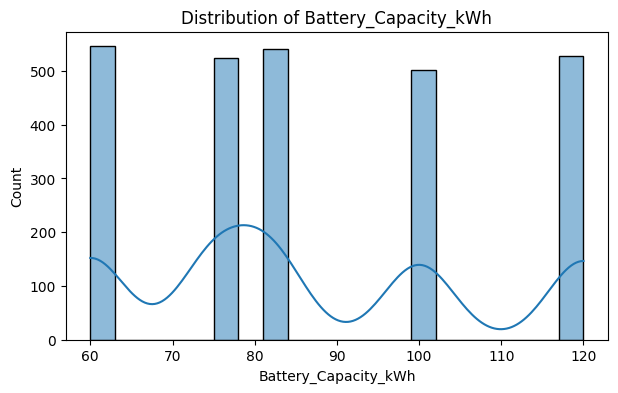

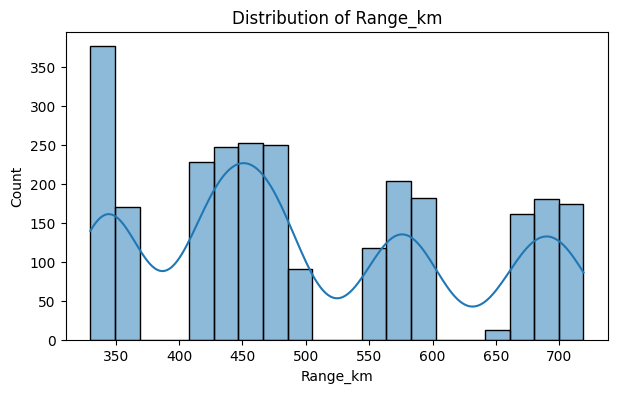

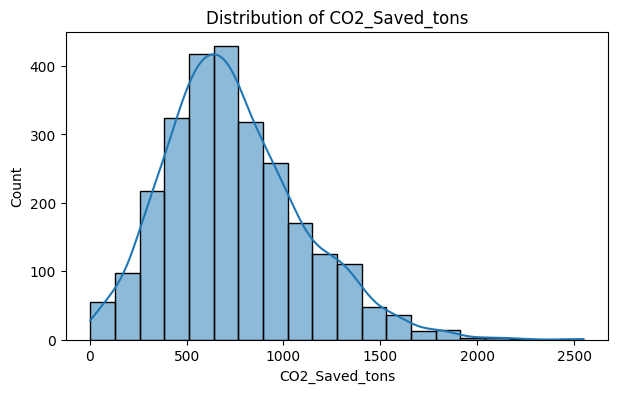

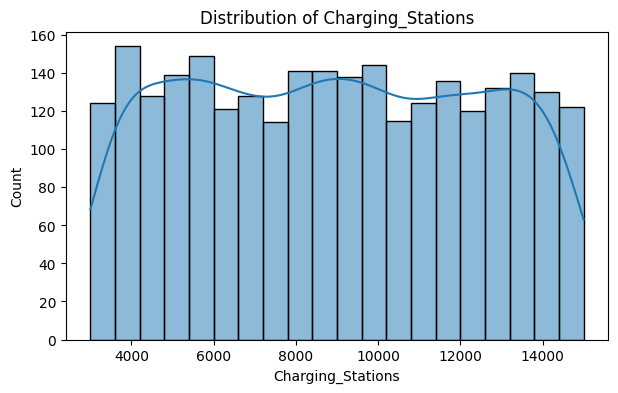

In [474]:
numerical_cols = data.select_dtypes(include=np.number).columns

for column in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data[column],
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)

    plt.show()

***Box plot for outlier detection***



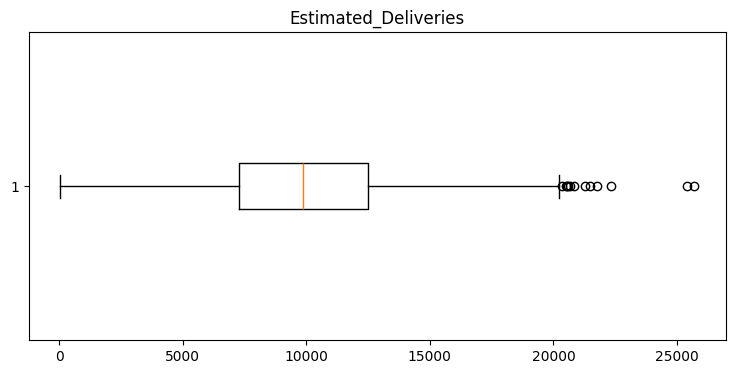

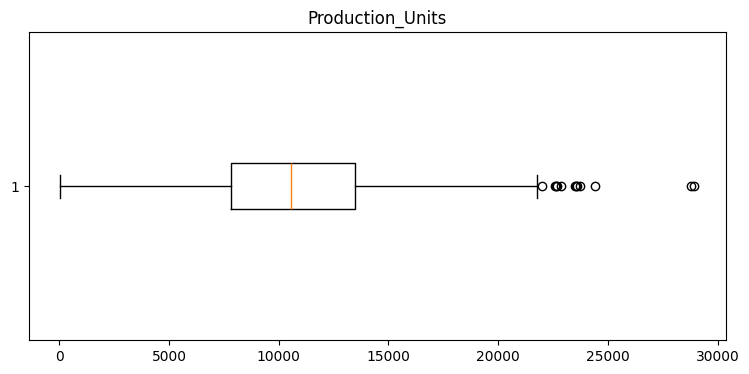

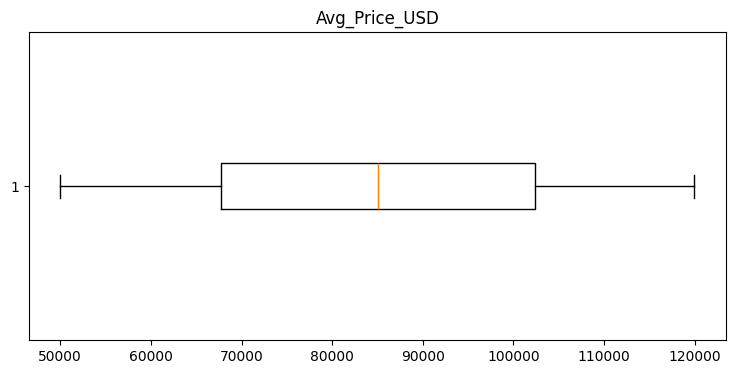

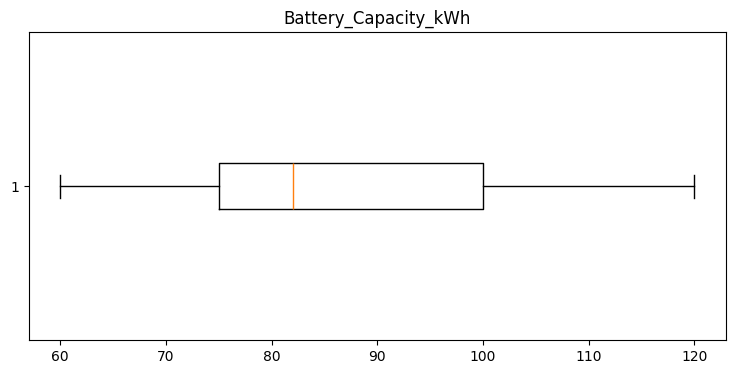

In [475]:
for col in num_cols:
  plt.boxplot(df[col],vert=False)
  plt.title(col)
  plt.show()

***Correlation Matrix***

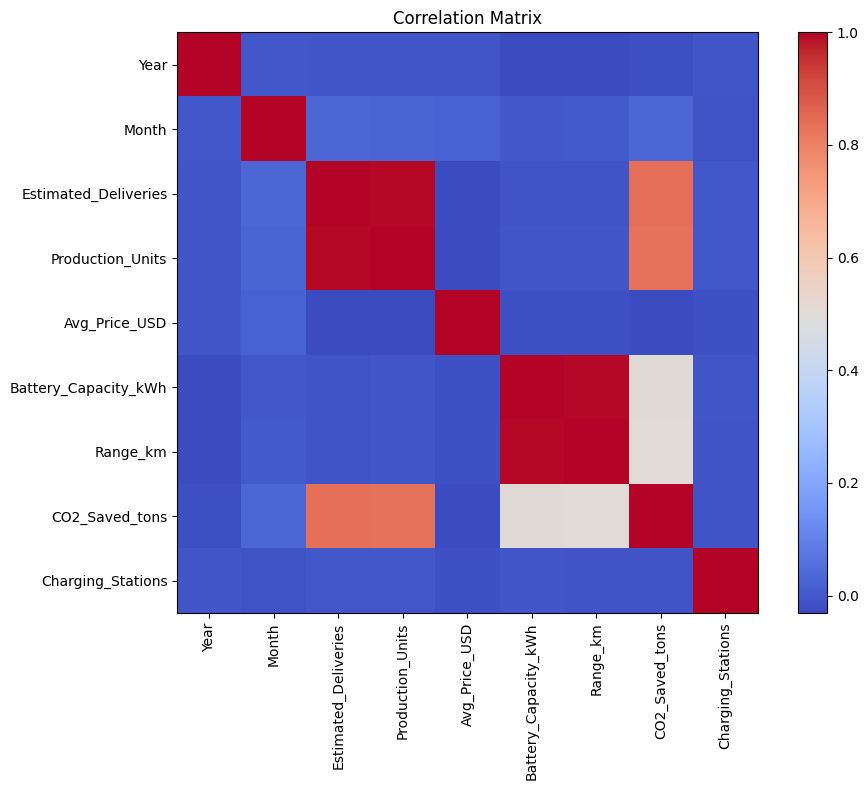

In [476]:
corr_matrix = df.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

***Annual Delivery & Production Trend***

Plotting yearly averages exposes long-term growth and the visible dip caused by COVID-19 in 2020.

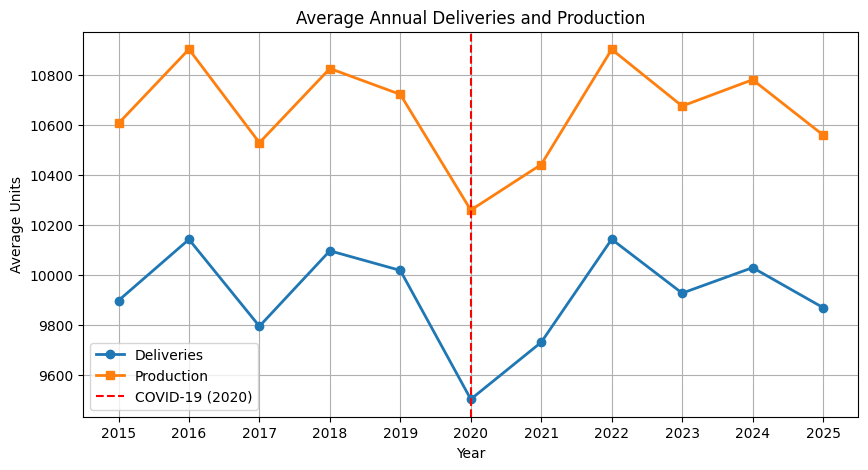

In [477]:
yearly = df.groupby("Year")[["Estimated_Deliveries", "Production_Units"]].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly["Estimated_Deliveries"],
         marker='o', linewidth=2, label="Deliveries")

plt.plot(yearly.index, yearly["Production_Units"],
         marker='s', linewidth=2, label="Production")

plt.axvline(2020, color="red", linestyle="--", label="COVID-19 (2020)")

plt.title("Average Annual Deliveries and Production")
plt.xlabel("Year")
plt.ylabel("Average Units")
plt.xticks(yearly.index)
plt.legend()
plt.grid(True)

plt.show()

***Outlier treatment***

Using the IQR method to detect outliers and clip them to the lower/upper fences.

In [478]:
for col in num_cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  low=Q1-1.5*IQR
  high=Q3+1.5*IQR

  outlier=df[(df[col]<low)|(df[col]>high)]
  df[col] = df[col].clip(low, high)     #clipping the outliers



  print(f"Total outlier in {col} column ; {len(outlier)}")

Total outlier in Estimated_Deliveries column ; 12
Total outlier in Production_Units column ; 12
Total outlier in Avg_Price_USD column ; 0
Total outlier in Battery_Capacity_kWh column ; 0


# Feature Engineering

In [479]:
def make_new_features(df):

    df = df.copy()

    # Creating Date from yeat and month
    df["Date"] = pd.to_datetime(
        df["Year"].astype(str) + "-" +
        df["Month"].astype(str) + "-01"
    )
    df = df.sort_values("Date").reset_index(drop=True)
    df["Quarter"] = ((df["Month"] - 1)//3) + 1
    df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"]

    # Adding Lag features
    df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
    df["Deliveries_Lag3"] = df["Estimated_Deliveries"].shift(3)

    # Adding Rolling Mean
    df["Deliveries_RollingMean_3"] = (
        df["Estimated_Deliveries"]
        .shift(1)
        .rolling(3)
        .mean()
    )

    df["COVID_Flag"] = (
        ((df["Year"] == 2020) &
         (df["Month"] >= 3) &
         (df["Month"] <= 9))
    ).astype(int)

    return df


df = make_new_features(df)

# Remove rows with NaN
df = df.dropna().reset_index(drop=True)

# Feature Selection

Checking correlation with Estimated_Deliveries to see which features are important.Also dropping non useful


In [480]:
corr = df.corr(numeric_only=True)

corr["Estimated_Deliveries"].sort_values(ascending=False)

,Estimated_Deliveries
Estimated_Deliveries,1.000000
Production_Units,0.994315
CO2_Saved_tons,0.836799
Deliveries_Lag3,0.041975
Quarter,0.036301
Month,0.031234
Deliveries_RollingMean_3,0.025618
Charging_Stations,0.001619
Year,-0.000931
Range_km,-0.006178


In [481]:
df.drop(columns=['Source_Type',"Production_Units","Month","Battery_Capacity_kWh"],inplace=True)

# Train-Test Split

In [482]:
X=df.drop(columns=["Estimated_Deliveries"])

y=df["Estimated_Deliveries"]


In [483]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,shuffle=False)

In [484]:
# For Numerical Features
num_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

# For Categorical Features
cate_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cate_features)

Numerical Features:
['Year', 'Avg_Price_USD', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter', 'Price_per_km', 'Deliveries_Lag1', 'Deliveries_Lag3', 'Deliveries_RollingMean_3', 'COVID_Flag']

Categorical Features:
['Region', 'Model']


# Preprocessing Pipelines

  *Used a ***ColumnTransformer*** with **StandardScaler** for numerical features and **OneHotEncoder** for categorical features*

In [485]:
num_pipe=Pipeline([
    ('scaler',StandardScaler())
])
cate_pipe=Pipeline([
    ('encoder',OneHotEncoder(drop="first"))
])
preprocess=ColumnTransformer([
    ('num',num_pipe,num_features),
    ('cate',cate_pipe,cate_features)
])


# Model 1 — Linear Regression

In [486]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocess),
        ("regressor", LinearRegression())
    ]
)
linear_pipeline.fit(X_train, y_train)
lr_y_pred = linear_pipeline.predict(X_test)

***Linear Model Evaluations***

In [487]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, lr_y_pred)
mse = mean_squared_error(y_test, lr_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_y_pred)


print("Linear Regression Performance\n\n")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance


MAE  : 605.94
MSE  : 713551.72
RMSE : 844.72
R²   : 0.9463


***Plotting Actual and Predicted Values on graph***

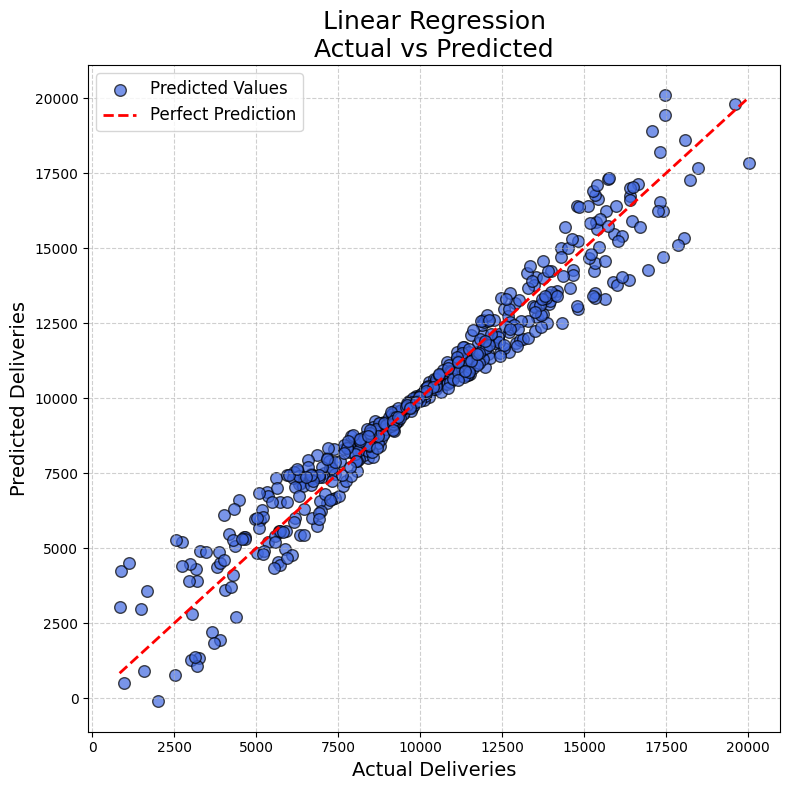

In [488]:
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(
    y_test,
    lr_y_pred,
    color="royalblue",
    alpha=0.7,
    s=70,
    edgecolor="black",
    label="Predicted Values"
)

#prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Linear Regression\nActual vs Predicted", fontsize=18)
plt.xlabel("Actual Deliveries", fontsize=14)
plt.ylabel("Predicted Deliveries", fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Model 2 — Decision Tree Regressor
Used  Decision Tree for capturing  non-linear patterns.

**hyperparameters used**:

max_depth=10

min_samples_split=10 / min_samples_leaf=2

ccp_alpha=0.01

In [489]:
from sklearn.tree import DecisionTreeRegressor
dt_pipe=Pipeline(
    steps=[
        ("preprocessor", preprocess),
        ("regressor", DecisionTreeRegressor(random_state=42,max_depth=10,min_samples_split=10,min_samples_leaf=2,ccp_alpha=0.01))
    ]
)
dt_pipe.fit(X_train, y_train)
dt_y_pred = dt_pipe.predict(X_test)

mae = mean_absolute_error(y_test,dt_y_pred)
mse = mean_squared_error(y_test, dt_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, dt_y_pred)

print("Decision Tree Regressor")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:4f}")

Decision Tree Regressor
MAE  : 235.34
MSE  : 110028.38
RMSE : 331.71
R²   : 0.991724


***Plotting Actual and Predicted Values on graph***

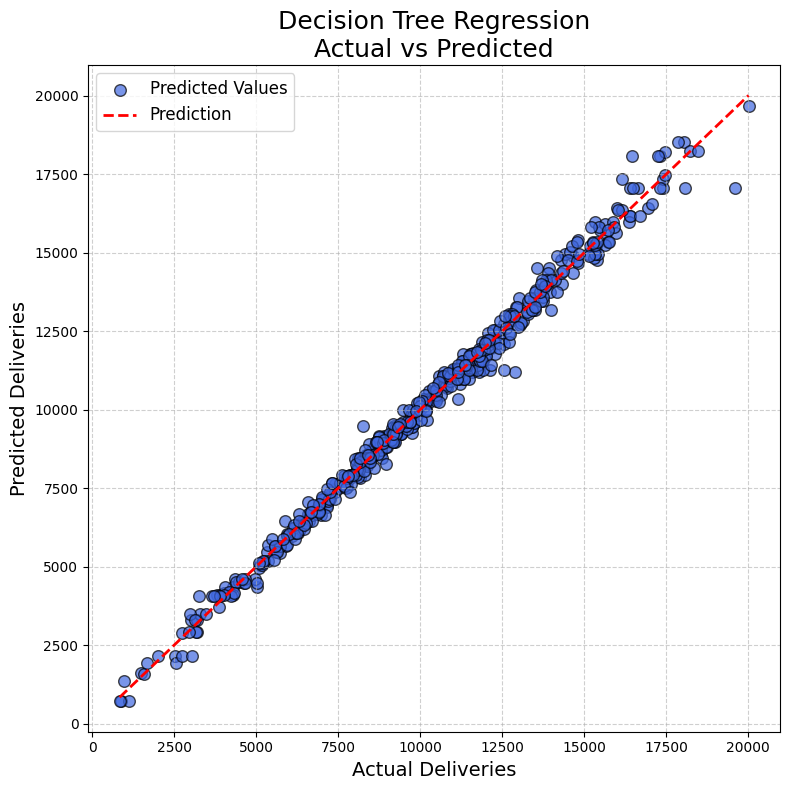

In [490]:
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(
    y_test,
    dt_y_pred,
    color="royalblue",
    alpha=0.7,
    s=70,
    edgecolor="black",
    label="Predicted Values"
)

#prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Prediction"
)


plt.title("Decision Tree Regression\nActual vs Predicted", fontsize=18)
plt.xlabel("Actual Deliveries", fontsize=14)
plt.ylabel("Predicted Deliveries", fontsize=14)

plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Model 3 — SARIMAX (Time-Series Forecasting)



*Unlike the regression models above, SARIMAX treats the data as a time series and models autocorrelation explicitly.*

In [491]:
import pandas as pd

# Creating a copy
ts_df = df.copy()

# Using the  Date as index columb
ts_df["Date"] = pd.to_datetime(ts_df["Date"])
ts_df = ts_df.sort_values("Date")

ts_df.set_index("Date", inplace=True)

# Target variable   (aggregate data by date to get one observation per time step.)
ts = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .sort_index()
)

ts.head()

,Estimated_Deliveries
Date,
2015-01-01,150485.000
2015-02-01,165053.000
2015-03-01,179494.625
2015-04-01,225623.000
2015-05-01,184264.000


In [492]:
ts_df = df.copy()
ts_df["Date"] = pd.to_datetime(ts_df["Date"])
ts_df = ts_df.sort_values("Date")

In [493]:
ts_agg = ts_df.groupby("Date").agg({
    "Estimated_Deliveries": "sum",
    "Avg_Price_USD": "mean",
    "Range_km": "mean",
    "CO2_Saved_tons": "sum",
    "Charging_Stations": "sum"
})

In [494]:
y = ts_agg["Estimated_Deliveries"]
X = ts_agg[["Avg_Price_USD", "Range_km", "CO2_Saved_tons", "Charging_Stations"]]

In [495]:
train_size = int(len(y) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]


***Model Training***

In [496]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)
print(sarimax_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  105
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 12)   Log Likelihood                -865.037
Date:                            Sun, 28 Jun 2026   AIC                           1746.074
Time:                                    19:14:51   BIC                           1766.073
Sample:                                01-01-2015   HQIC                          1754.139
                                     - 09-01-2023                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Avg_Price_USD         0.0432      0.147      0.294      0.769      -0.245       0.331
Range_km      

***Forecast & Evaluation***







In [497]:
forecast = sarimax_results.get_forecast(steps=len(y_test), exog=X_test)
y_pred = forecast.predicted_mean

In [498]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("SARIMAX Performance (Seasonal + Exogenous)\n\n")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

SARIMAX Performance (Seasonal + Exogenous)


MAE  : 3348.22
MSE  : 17162400.20
RMSE : 4142.75
R²   : 0.8922


**Actual vs Forecast Plot**

*The shaded band represents the 95% confidence interval around the SARIMAX forecast, giving a sense of prediction uncertainty.*

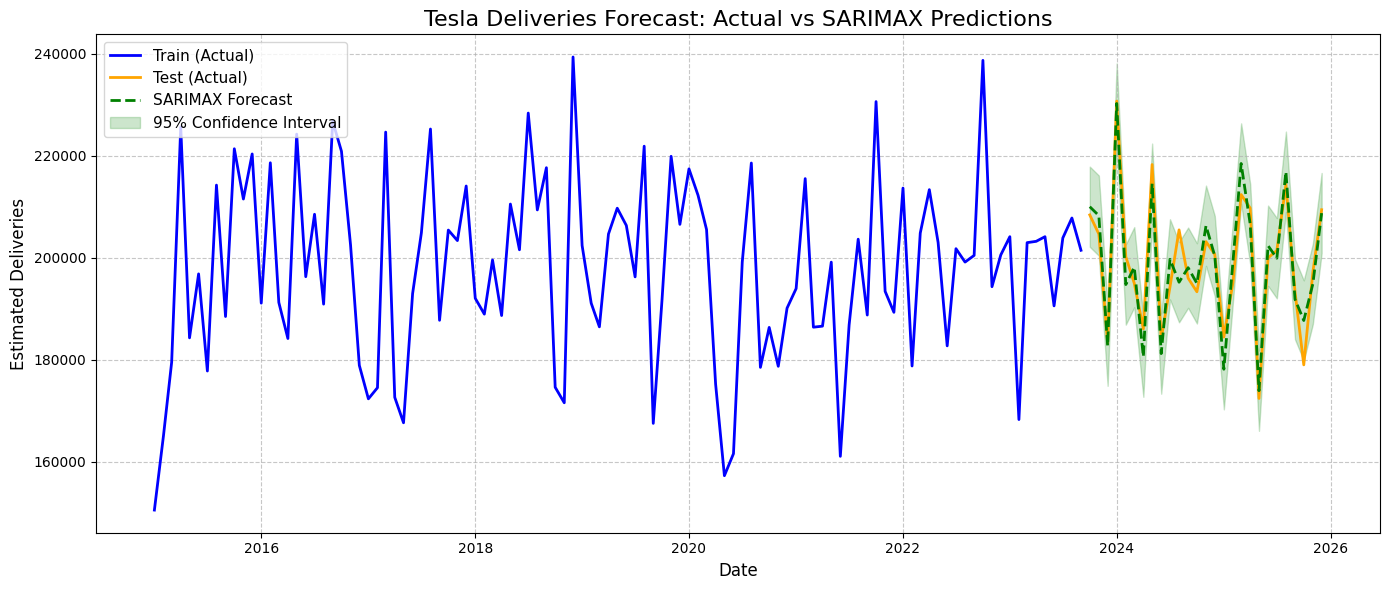

In [499]:

conf_int = forecast.conf_int()
plt.figure(figsize=(14, 6))

# Plot Training Data
plt.plot(y_train.index, y_train, label='Train (Actual)', color='blue', linewidth=2)

# Plot Test Data
plt.plot(y_test.index, y_test, label='Test (Actual)', color='orange', linewidth=2)

# Plot SARIMAX Forecast
plt.plot(y_pred.index, y_pred, label='SARIMAX Forecast', color='green', linestyle='--', linewidth=2)

# Plot Confidence Interval (Shaded Area)
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],  # Lower bound
    conf_int.iloc[:, 1],  # Upper bound
    color='green',
    alpha=0.2,
    label='95% Confidence Interval'
)

# Formatting the plot
plt.title('Tesla Deliveries Forecast: Actual vs SARIMAX Predictions', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Estimated Deliveries', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()